## Bet size distribution

To understand what players' normal betsize behaviors are, we first need to find their betsize distribution.  
    
What we aim to find is the typical bet size and how spread out the  bet sizes are across the dataset.

We expect that most of the players will bet in small amounts, and there will be some outliers that bet large amounts  of money. If this expectation ends up being true, then using the median instead of the mean is a better representation of betting behavior across the whole dataset

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from poker_coach.config import BUSTABIT_DATA_FILE

sns.set_theme(style="darkgrid")

df = pd.read_csv(BUSTABIT_DATA_FILE)
print(len(df), df.memory_usage(deep=True).sum() / 1024**2)

print(df.head(5))


50000 8.681303977966309
         Id   GameID   Username  Bet  CashedOut  Bonus  Profit  BustedAt  \
0  14196549  3366002      papai    5       1.20    0.0    1.00      8.24   
1  10676217  3343882     znay22    3        NaN    NaN     NaN      1.40   
2  15577107  3374646   rrrrrrrr    4       1.33    3.0    1.44      3.15   
3  25732127  3429241  sanya1206   10        NaN    NaN     NaN      1.63   
4  17995432  3389174        ADM   50       1.50    1.4   25.70      2.29   

               PlayDate  
0  2016-11-20T19:44:19Z  
1  2016-11-14T14:21:50Z  
2  2016-11-23T06:39:15Z  
3  2016-12-08T18:13:55Z  
4  2016-11-27T08:14:48Z  


We will create a histogram of every bet made throughout the entire dataset and show the distribution of bets across players.

We expect to see that there is a right-skewed distribution where most players bet small amounts of money and some outliers bet very large amounts.

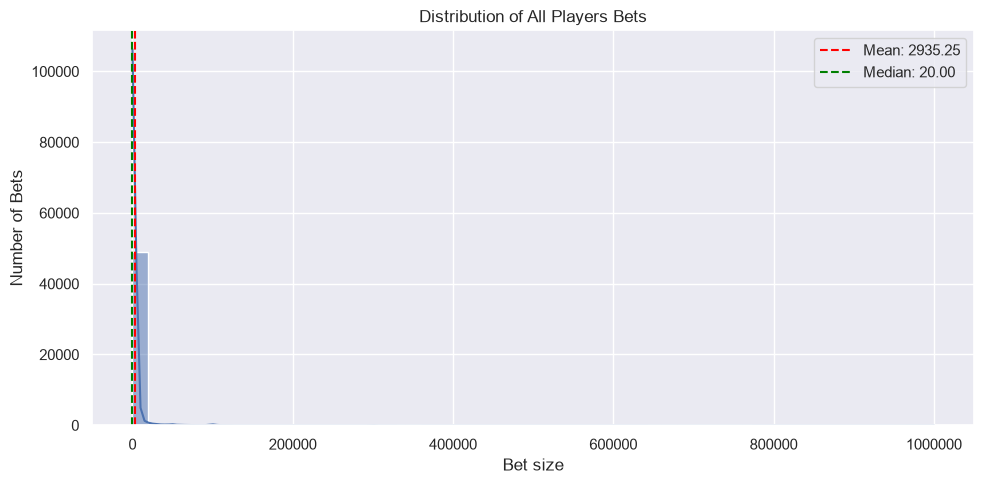

In [6]:

plt.figure(figsize=(10,5))
plt.title('Distribution of All Players Bets')
plt.xlabel('Bet size')
plt.ylabel('Number of Bets')
ax = sns.histplot(df['Bet'], bins=50, kde=True)

ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

def add_median_and_mean():
    #Adding vertical  lines that  represent the mean and median bets size  
    mean_bet = df['Bet'].mean()
    median_bet = df['Bet'].median()

    plt.axvline(mean_bet, color= 'red', linestyle='--', label=f"Mean: {mean_bet:.2f}")
    plt.axvline(median_bet, color= 'green', linestyle='--', label=f"Median: {median_bet:.2f}")
    plt.legend()

add_median_and_mean()

plt.tight_layout()
plt.show()


This chart proves our hypothesis that most players generally bet small amounts of money and there are some outliers that bet large amounts of money. 

The chart has a large skew that makes it difficult to see majority of the bets look like since theyre all getting pushed to one part. 

To help visualize it better we can use a logarithmic scale that increases by multiples of ten

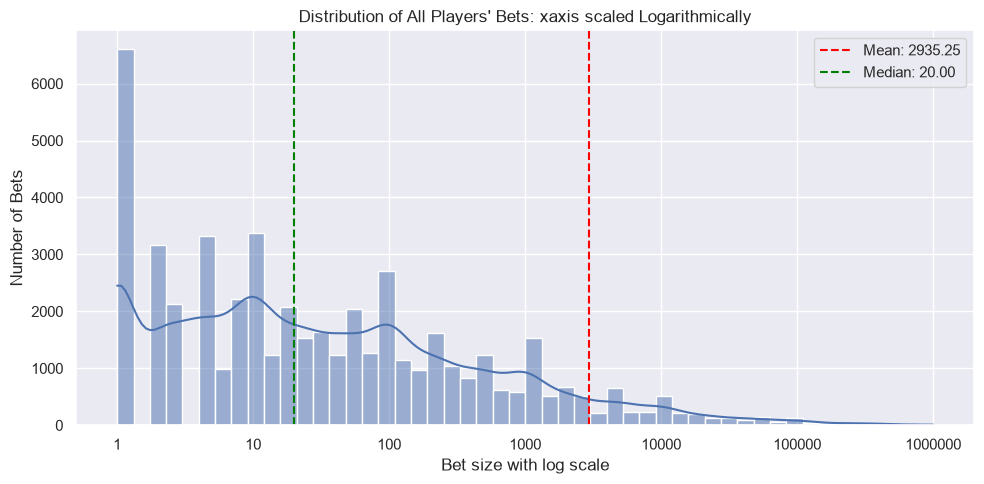

In [7]:
plt.figure(figsize=(10,5))
plt.title("Distribution of All Players\' Bets: xaxis scaled Logarithmically")
plt.xlabel('Bet size with log scale')
plt.ylabel('Number of Bets')
ax = sns.histplot(df['Bet'], bins=50, kde=True, log_scale=True)

ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

add_median_and_mean()

plt.tight_layout()
plt.show()



In [8]:
print(f"Mean bet: {df['Bet'].mean():.2f}")
print(f"Median bet: {df['Bet'].median():.2f}")

Mean bet: 2935.25
Median bet: 20.00


The mean of Bet sizes was much bigger than the median. This is due to the outlier whales, which caused the mean to be very large since they bet an extremely high amount relative to the rest of the players. 

The median represents the player base better since it is where most of the playres bets actually are. The huge gap between the lines for mean and median serves as a visual proof of how much outliers can skew results. 